# CAPSTONE: Analysis of Sales and Customers' beaviour (Supermarket Sales)
### Prepared by: Vytaute Povilanskaite (Data Analysis 12-11-2025 group; Capstone project at Baltic Institute of Technology for Data Analysis)

**Data Set:** Supermarket Sales 
https://www.kaggle.com/datasets/faresashraf1001/supermarket-sales

#### Environment setup before data processing

In [ ]:
# Downloading the necessary libraries. The list may be adjusted and expanded as needed throughout the process

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Regression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

#### 1. Importing data

In [36]:
# Importing dataset using 'raw string' method

df = pd.read_csv(r"C:\Users\linke\Desktop\BIT final lab\SuperMarket Analysis.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


The data was loaded successfully, and the dataset structure appears consistent. The first five rows align logically with the corresponding column names.

#### 2. Data Exploration and Preparation

In [37]:
df.shape

(1000, 17)

In [38]:
df.columns.tolist()

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Sales',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [40]:
df.isna().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

We can see that the initial dataset consists of 1,000 rows and 17 columns. There are no missing values in any of the columns.

The dataset contains different data types: 7 columns are of type float (floating-point numbers), 1 column is of type int (integer), and 9 columns are of type str (text). The Date and Time columns should be converted to the datetime format for further analysis.

In [41]:
# I combine the Date and Time columns into a single Datetime column, which will allow for more efficient and convenient time-based analysis later on. 
# The original Date and Time columns are then removed to reduce redundancy and avoid unnecessary noise in the dataset.

df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%m/%d/%Y %I:%M:%S %p"
)

df = df.drop(columns=["Date", "Time"])

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Payment,cogs,gross margin percentage,gross income,Rating,datetime
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00


In [42]:
# I create several additional time-based features to enable more comprehensive temporal analysis throughout the project

df["Hour"] = df["datetime"].dt.hour
df["Weekday"] = df["datetime"].dt.day_name()
df["Month"] = df["datetime"].dt.month

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Payment,cogs,gross margin percentage,gross income,Rating,datetime,Hour,Weekday,Month
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00,13,Saturday,1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00,10,Friday,3
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00,13,Sunday,3
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00,20,Sunday,1
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00,10,Friday,2


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   str           
 1   Branch                   1000 non-null   str           
 2   City                     1000 non-null   str           
 3   Customer type            1000 non-null   str           
 4   Gender                   1000 non-null   str           
 5   Product line             1000 non-null   str           
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Payment                  1000 non-null   str           
 11  cogs                     1000 non-null   float64       
 12  gross margin percentage  1000 non-null   float

In [15]:
df.select_dtypes(include="number").columns

Index(['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'cogs',
       'gross margin percentage', 'gross income', 'Rating', 'Hour', 'Month'],
      dtype='str')

After data preparation, the dataset has the following structure: 1,000 rows and 19 columns.

Data types:

Invoice ID – text;
Branch – text;
City – text;
Customer type – text;
Gender – text;
Product line – text;
Unit price – floating-point number;
Quantity – integer;
Tax 5% – floating-point number;
Sales – floating-point number;
Payment – text;
COGS – floating-point number;
Gross margin percentage – floating-point number;
Gross income – floating-point number;
Rating – floating-point number;
Datetime (date and time) – datetime;
Hour – integer;
Weekday – text;
Month – integer.

The dataset contains 10 columns with numerical values, which can be used for statistical analysis and visualization.


#### 3. Exploratory Data Analysis (EDA)

In [44]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Unit price,1000.0,55.67213,10.08,32.875,55.23,77.935,99.96,26.494628
Quantity,1000.0,5.51,1.0,3.0,5.0,8.0,10.0,2.923431
Tax 5%,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Sales,1000.0,322.966749,10.6785,124.422375,253.848,471.35025,1042.65,245.885335
cogs,1000.0,307.58738,10.17,118.4975,241.76,448.905,993.0,234.17651
gross margin percentage,1000.0,4.761905,4.761905,4.761905,4.761905,4.761905,4.761905,0.0
gross income,1000.0,15.379369,0.5085,5.924875,12.088,22.44525,49.65,11.708825
Rating,1000.0,6.9727,4.0,5.5,7.0,8.5,10.0,1.71858
datetime,1000,2019-02-14 15:30:27.480000,2019-01-01 10:39:00,2019-01-24 17:58:45,2019-02-13 17:37:00,2019-03-08 15:29:30,2019-03-30 20:37:00,NaN
Hour,1000.0,14.91,10.0,12.0,15.0,18.0,20.0,3.186857


In [45]:
# Median value

df[["Sales", "Quantity"]].median()

Sales       253.848
Quantity      5.000
dtype: float64

Before conducting a more detailed analysis of the numerical variables, it is important to note that an initial overview indicates that the data is generally clean and well-structured across all numerical fields, with the exception of gross margin percentage, Tax 5%, and gross income.

The gross margin percentage variable has the same value for every observation. Its mean, percentiles, minimum, and maximum values are all equal to 4.76. In a real-world retail environment, it is unlikely that the profit margin would be identical for every sale. However, since this is a synthetic dataset, it is likely that this value was intentionally fixed during dataset generation.

The Tax 5% and gross income variables are also identical throughout the dataset. In this dataset, Tax 5% is calculated as 5% of COGS (Cost of Goods Sold), while gross income is calculated as Sales − COGS. Although these variables represent different business concepts, their values are numerically identical for every observation. This characteristic should be considered when interpreting the results, but the variables will be retained in the dataset.

Although the sales were recorded in Myanmar, whose official currency is the Myanmar Kyat (MMK), the summary statistics clearly indicate that the monetary values in this dataset are not expressed in kyat. Given that 1 EUR is approximately equal to several thousand MMK, the recorded monetary amounts are far too small to represent transactions in kyat. The values are more likely denominated in a currency such as US dollars (USD) or British pounds (GBP). However, because the actual currency is not specified, all monetary values will hereafter be referred to simply as currency units.

Let's take a closer look at Sales and Quantity variables:

Sales: mean - 322.97, median - 253.85, std - 245.86, min - 10.68, max - 1042.65

Quantity: mean - 5.51, median - 5, std - 2.92, min - 1, max - 10

The summary statistics for Quantity suggest a relatively balanced and well-behaved distribution. The mean and median are close to each other, and the standard deviation is moderate relative to the variable's range.

In contrast, the statistics for Sales indicate a potentially non-normal distribution and the possible presence of outliers. The median is considerably lower than the mean, suggesting right-skewness, while the relatively large standard deviation points to substantial variability in sales values.

To better understand the underlying distributions and assess the presence of skewness or outliers, the variables will be examined further using graphical visualizations.

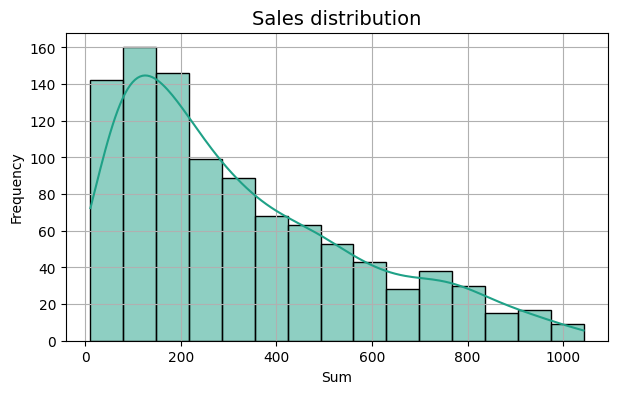

In [46]:
# 1. Histogram with KDE (Sales Distribution)

plt.figure()
sns.histplot(df['Sales'], kde=True, color=sns.color_palette("viridis")[3])
plt.title('Sales distribution', fontsize=14)
plt.xlabel('Sum')
plt.ylabel('Frequency')
plt.show()

The histogram shows a right-skewed distribution, meaning that the highest concentration of sales occurs at lower transaction values, around 100 currency units. As the transaction amount increases, the frequency of sales gradually decreases, with several high-value transactions appearing as potential outliers.

Most sales are below 300 currency units, suggesting that the supermarket primarily relies on small-basket purchases, while large transactions are relatively rare and mostly isolated cases.

The distribution is clearly non-normal, which makes the median a more representative measure of central tendency than the mean when describing a typical customer's purchasing behavior. Therefore, throughout the EDA, the median will be used to analyze typical sales patterns, while the mean will be used when evaluating overall revenue levels and business performance.

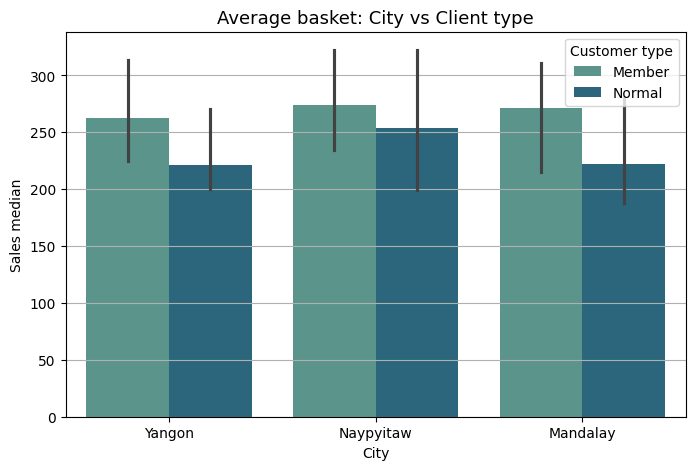

In [47]:
# 2. Sales Performance by City and Customer Type
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='City', y='Sales', hue='Customer type', palette='crest', estimator=np.median)
plt.title('Average basket: City vs Client type', fontsize=13)
plt.ylabel('Sales median')
plt.show()

To gain a deeper understanding of customer behavior, we examined whether there are differences between regular customers and members. The results show that in all cities, members have a higher median basket value than non-members. This suggests that registered or loyal customers tend to spend more per transaction.

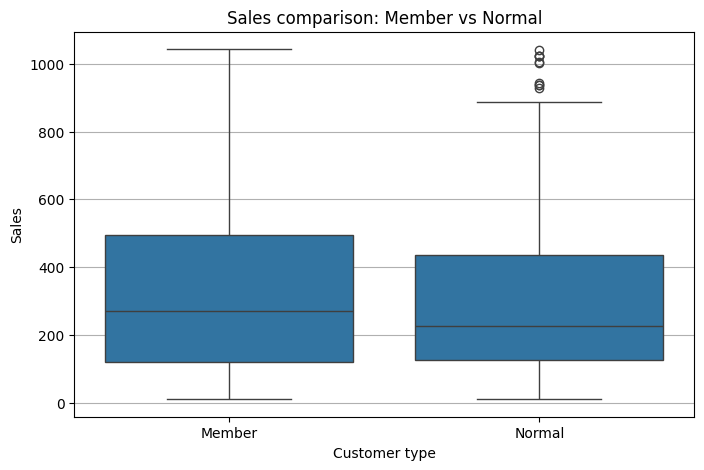

In [49]:
#3. Boxplot Comparing Sales Distributions Between Members and Non-Members

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Customer type",
    y="Sales"
)

plt.title("Sales comparison: Member vs Normal")
plt.show()

The boxplots reveal notable differences between the two customer groups. In the Normal customer segment, there are numerous high-value outliers, indicating that while most purchases are relatively small, some transactions are exceptionally large. In contrast, the Member group shows few or no extreme outliers, suggesting a more stable purchasing pattern, even though the overall spread of purchase values is wider.

These results indicate that members tend to purchase more consistently, with transaction amounts distributed across a broader range but without the presence of extreme one-off purchases. The wider spread suggests greater variability in spending behavior among members, while the absence of major outliers points to a more predictable customer segment.

The median values further confirm the right-skewed distribution observed in both groups, where a relatively small number of high-value purchases pull the mean above the median.

Based on these observations, it is reasonable to cautiously hypothesize that the difference between members and non-members may be statistically significant when evaluating whether members generate greater customer value. This assumption will be tested later using a two-sample t-test.

Although the underlying sales distributions are not normally distributed, the sample size is sufficiently large (n = 1,000) for the Central Limit Theorem to apply. As a result, the sampling distribution of the mean is expected to be approximately normal, making the t-test a suitable and reliable method for comparing group means.

To further validate the results and avoid relying solely on the normality assumption, a Mann–Whitney U test will also be performed. This non-parametric test does not require normally distributed data and will provide an additional layer of confidence in the conclusions.

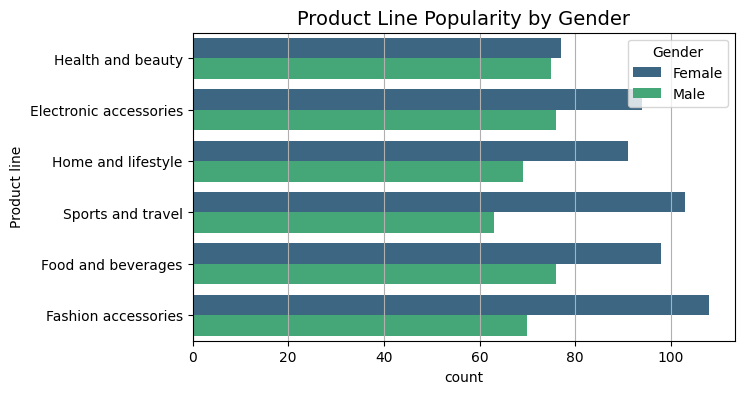

In [50]:
# 4. Product Line Popularity by Gender
plt.figure()
sns.countplot(data=df, y='Product line', hue='Gender', palette="viridis")
plt.title('Product Line Popularity by Gender', fontsize=14)
plt.show()

Out of curiosity, we also examined product line popularity by gender. The chart clearly shows that female customers purchase more items across all product categories compared to male customers.

The most noticeable differences between genders are observed in the Sports and Travel and Fashion Accessories categories, where the gap is relatively large. In contrast, the smallest difference is seen in the Health and Beauty category, where purchasing behavior between males and females is almost identical.

Since no detailed product-level information is available, it is not possible to further analyze which specific items are driving these differences. Such an analysis would be interesting and valuable for deeper insights, but in this case, we can only draw general conclusions at the category level.

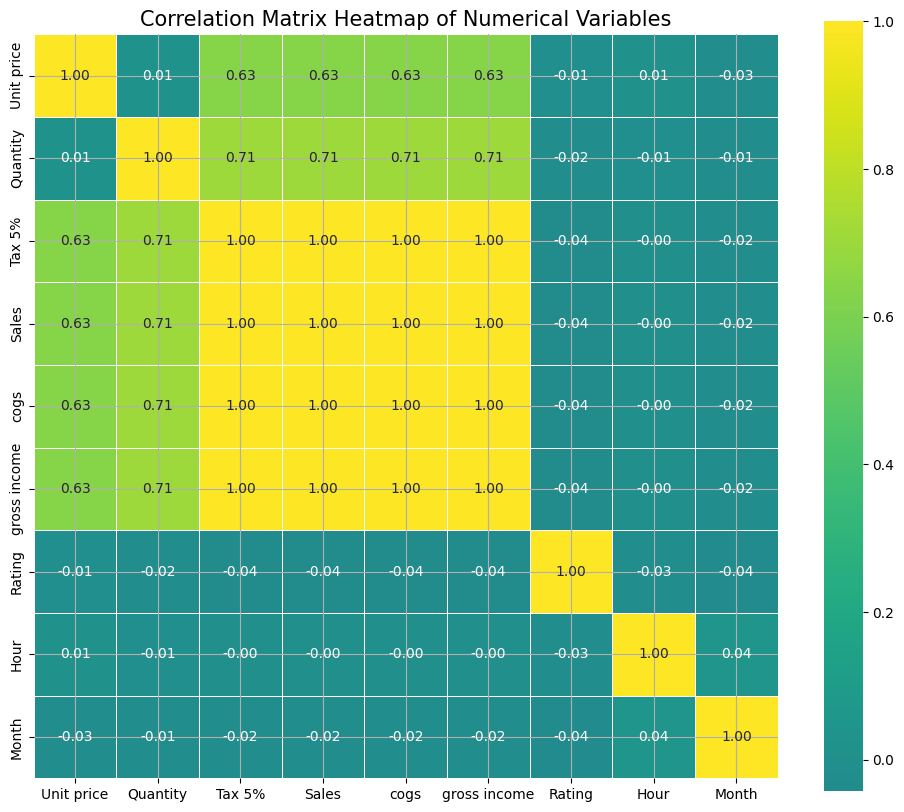

In [51]:
# 5. Correlation Matrix Heatmap of Numerical Variables

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

to_drop = ['gross margin percentage'] 

final_cols = [col for col in numeric_cols if col not in to_drop]

corr_matrix = df[final_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='viridis',
            center=0, 
            square=True, 
            linewidths=.5)

plt.title('Correlation Matrix Heatmap of Numerical Variables', fontsize=15)
plt.show()

We observe multicollinearity, including a perfect correlation (1.00) between Sales, Tax 5%, COGS, and Gross income. These variables are directly derived from one another, meaning they do not provide independent information. As a result, they should be interpreted with caution, as they may introduce redundancy. In a predictive modeling context, they would likely need to be excluded to avoid misleading the model or inflating its performance.

At this stage, these variables can be considered partially redundant, although they still reflect consistent internal relationships within the dataset.

Additionally, we observe a strong positive correlation between Sales and Quantity, indicating that higher sales are largely driven by the number of items purchased. There is also a moderate positive correlation between Sales and Unit price, suggesting that both price and quantity contribute to overall sales values.

For a more comprehensive understanding, future analysis should incorporate categorical variables, which may help explain additional variation in the data that is not captured by numerical relationships alone.

#### 4. 95% Confidence Interval (CI)

##### We calculate the confidence interval for the Rating variable. This will allow us to estimate the range within which the true customer satisfaction level is likely to vary.

In [52]:

col = "Rating" 
x = df[col].dropna().astype(float).values
n = len(x)
mean = x.mean()
std = x.std(ddof=1)

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
se = std / np.sqrt(n)

ci_low = mean - t_crit * se
ci_high = mean + t_crit * se

print(f"Mean: {mean:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")


Mean: 6.97
95% CI: [6.87, 7.08]


The obtained result, [6.68, 7.08], indicates that we are 95% confident that the true population mean of customer ratings falls within this interval. While individual customers may rate the supermarket differently (with observed ratings ranging from 4 to 10), the overall level of satisfaction is relatively stable, with a mean of approximately 6.97.

If we assume a standard 1–10 rating scale, the theoretical midpoint would be 5.5. The observed mean of 6.97 therefore suggests that overall customer satisfaction is above the neutral midpoint, indicating a generally positive evaluation of the supermarket experience.

Although the score cannot be considered exceptionally high, it reflects a moderately positive satisfaction level, and importantly, no extremely low ratings were observed. Additionally, since the upper bound of the confidence interval exceeds 7, there is potential for satisfaction levels to be even higher under different conditions or improvements.

#### 5. Hypothesis Testing (H0 ir Ha)

For hypothesis testing, we will use the Sales variable to examine whether there is a statistically significant difference in average purchase amounts between Member and Normal customers. The analysis will be conducted using a Welch’s t-test, and the results will be validated using the Mann–Whitney U test.

This choice is made because of the right-skewed distribution of the Sales variable. However, due to the relatively large sample size (n = 1,000) and the Central Limit Theorem (CLT), we assume that the sampling distribution of the mean is approximately normal, which satisfies the assumptions required for the t-test.

To leave no doubt, we also apply the Mann–Whitney U test, which compares the distributions of the two groups based on ranks rather than raw values. This non-parametric test does not assume normality and evaluates whether values in one group tend to be systematically higher than in the other.

1. Formulation of hypotheses:

- H₀ (Null Hypothesis): The mean purchase amounts (Sales) do not differ between the Member and Normal customer groups.
- H₁ (Alternative Hypothesis): The mean purchase amounts (Sales) differ significantly between the Member and Normal customer groups.

2. Hypothesis testing using Welsh T-test:

In [53]:
group = "Customer type"
target = "Sales"

g_member = df.loc[df[group] == "Member", target]
g_normal = df.loc[df[group] == "Normal", target]

t_stat, p_val = stats.ttest_ind(g_member, g_normal, equal_var=False)

mean_member = g_member.mean()
mean_normal = g_normal.mean()
diff_means = mean_member - mean_normal

print(f"t-stats: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Member mean: {mean_member:.2f}")
print(f"Normal mean: {mean_normal:.2f}")
print(f"Difference: {diff_means:.2f}")

t-stats: 1.8862
p-value: 0.0596
Member mean: 335.74
Normal mean: 306.37
Difference: 29.37


After applying the t-test, the results are borderline. Since the p-value is greater than the chosen significance level (α = 0.05), we do not reject the null hypothesis (H₀). This suggests that there is no statistically significant difference in mean purchase amounts between the Member and Normal customer groups.

However, the p-value is very close to the significance threshold, which indicates a potential weak effect or borderline significance. Considering that the Sales distribution is right-skewed, it is important to further validate the results using the Mann–Whitney U test.

In [54]:
# Performing Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(df['Sales'])

print("--- Shapiro-Wilk test results ---")
print(f"Stats: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.10f}")

# Interpretation
if shapiro_p > 0.05:
    print("\nConclusion: The data is normally distributed (p > 0.05).")
else:
    print("\nConclusion: The data is not normally distributed (p <= 0.05).")

--- Shapiro-Wilk test results ---
Stats: 0.9088
p-value: 0.0000000000

Conclusion: The data is not normally distributed (p <= 0.05).


Once again we validate that the data is not normally distributed using Shapiro-Wilk test. Then we move on to perform the Mann Whitney U.

In [55]:
u_stat, p_val_mw = stats.mannwhitneyu(g_member, g_normal, alternative='two-sided')

median_member = g_member.median()
median_normal = g_normal.median()

print(f"Mann-Whitney U statistics: {u_stat:.2f}")
print(f"Mann-Whitney p-value: {p_val_mw:.4f}")
print(f"Member median: {median_member:.2f}")
print(f"Normal median: {median_normal:.2f}")

Mann-Whitney U statistics: 130784.00
Mann-Whitney p-value: 0.0812
Member median: 271.95
Normal median: 225.79


This result confirms that we cannot reject the null hypothesis (H₀). Although the p-value (0.0812) is relatively low, it still exceeds the standard significance threshold of α = 0.05. This means that there is no statistically significant difference in average purchase amounts between the groups.

However, the practical differences between the groups are noticeable. The mean difference amounts to 29.37 currency units, while the difference in medians is even larger at 46.16 currency units. Although these differences are not statistically significant at the chosen threshold, they suggest that Member customers tend to spend more per transaction on average.

From a business perspective, these findings may still be meaningful. Depending on the company’s strategy, they could support decisions such as strengthening the loyalty program to potentially amplify this effect or, alternatively, reassessing its impact.

A more detailed analysis could explore whether statistically significant differences emerge within specific product categories or customer segments. However, for the scope of this work, we conclude the hypothesis testing here and proceed to regression analysis and predictive modeling. This next step will allow us to evaluate how factors such as city, product line, and purchase timing jointly influence overall sales performance.

#### 6. Regression analysis

We will perform a regression analysis to evaluate how much of the variation in the Sales variable can be explained by the other variables in the dataset. Due to perfect multicollinearity with Sales, the variables cogs, Tax 5%, and gross income are excluded from the model.

We include Unit price and Quantity, which are expected to explain a substantial portion of the variance in sales, as they are directly related to transaction value.

We also include Branch, while excluding City, since these variables represent overlapping information. Customer type is included despite earlier findings showing no statistically significant differences, as it allows us to verify the correctness of the dummy encoding and its potential contribution in a multivariate setting.

Gender is included based on earlier observations suggesting slight differences in purchasing behavior. Product line and Payment are added because their relationship with sales has not yet been fully explored.

The Hour variable is also included out of exploratory interest, even though earlier correlation analysis suggested weak or negligible relationships with Sales. To avoid unnecessary model complexity, Month and Weekday are excluded due to their minimal explanatory power observed in prior analysis.

This model setup allows us to balance prior knowledge with exploratory testing, while maintaining interpretability and avoiding redundancy in the feature set.

In [56]:
# 1. Setting up target and features
target = "Sales"
feature_cols = ["Unit price", "Quantity", "Branch", "Customer type", "Gender", "Product line", "Payment", "Hour"]

X_raw = df[feature_cols].copy()
y = df[target].astype(float)

# 2. Dummy variables and float convertion 
X = pd.get_dummies(X_raw, drop_first=True).astype(float)

# 3. Data splitting into Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. OLS model training
# Adding intercept term, as statsmodels does not include it by default
X_train_ols = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_ols).fit()

# Model summary (for the coef)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     441.9
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:31:55   Log-Likelihood:                -4656.8
No. Observations:                 800   AIC:                             9344.
Df Residuals:                     785   BIC:                             9414.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

The regression analysis shows that the model has a very high explanatory power, with an R² value of 0.887. This means that the model explains 88.7% of the variance in Sales. The remaining ~11% is attributed to factors not included in the model or to random variation.

The results indicate that only two variables have statistically significant p-values (p < 0.05), suggesting that they are the main drivers of Sales: Unit price and Quantity. In practical terms, this implies that sales are primarily driven by how many items customers purchase and at what price.

Among these, Quantity is the most influential variable. Its coefficient of 58.09 indicates that, holding all other factors constant, each additional item in the basket increases total sales by approximately 58.09 currency units. Similarly, the Unit price coefficient of 5.82 suggests that a one-unit increase in price leads to an average increase of 5.82 currency units in total sales, assuming all other variables remain unchanged.

Variables such as customer loyalty status, gender, branch, and purchase hour are not statistically significant in the presence of Quantity and Unit price, indicating that their effect on sales is negligible once core transaction factors are accounted for.

Finally, the Durbin–Watson statistic of 2.084 is very close to 2, suggesting that there is no significant autocorrelation in the residuals. This supports the assumption that the model errors are independent.

In [57]:
# Model Evaluation on the Test Set (Predictions and Metrics)
X_test_ols = sm.add_constant(X_test)
pred_test = model.predict(X_test_ols)

r2 = r2_score(y_test, pred_test)
mae = mean_absolute_error(y_test, pred_test)
rmse = mean_squared_error(y_test, pred_test) ** 0.5

results = {"R2_test": r2, "MAE_test": mae, "RMSE_test": rmse}
print("\nModel evaluation metrics:")
print(results)


Model evaluation metrics:
{'R2_test': 0.9014165076591418, 'MAE_test': 59.52059007910722, 'RMSE_test': 80.08585426378546}


The test set metrics show that the model performs very well, with an R² of 0.901. This indicates that the selected features explain approximately 90% of the variance in Sales.

However, the MAE (Mean Absolute Error) is relatively high at 59.5, meaning that, on average, the model’s predictions deviate from the actual values by 59.5 currency units. This is a considerable error when compared to the average purchase value of around 322.

The model is further penalized by a higher RMSE (Root Mean Squared Error) of 80.08, which suggests that larger errors have a strong impact on overall performance. The fact that RMSE is significantly higher than MAE indicates the presence of larger deviations in some predictions.

This behavior is likely driven by outliers and occasional high-value transactions (around 1000 currency units), which disproportionately affect RMSE. While the model captures the overall trend well, individual predictions can vary substantially due to the inherent variability of purchase behavior. This is also supported by the boxplot shown below, which highlights the presence of extreme values in the data.

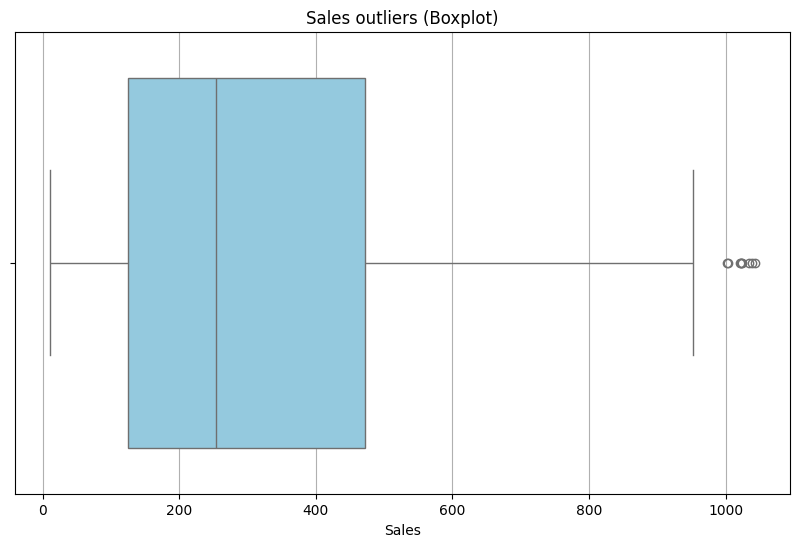

In [58]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Sales'], color='skyblue')
plt.title('Sales outliers (Boxplot)')
plt.xlabel('Sales')
plt.show()

To further assess model robustness and reliability, a VIF (Variance Inflation Factor) test was performed to check for multicollinearity among the independent variables. The results show that most variables are within acceptable limits, indicating no serious multicollinearity issues.

However, the Hour variable shows a high VIF value (approximately 11), suggesting the presence of multicollinearity. This indicates that Hour is highly correlated with other predictors in the model, which can inflate coefficient variance and reduce interpretability.

To maintain model stability and satisfy regression assumptions, the Hour variable is removed. The model is then retrained to ensure cleaner estimates and improved reliability of the coefficients.

In [59]:
# We calculate the VIF (Variance Inflation Factor) for each column in the feature X used in the OLS model.
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                             Feature        VIF
2                               Hour  11.366136
0                         Unit price   4.903095
1                           Quantity   4.163564
13                   Payment_Ewallet   1.988037
3                       Branch_Cairo   1.957882
4                        Branch_Giza   1.937520
7   Product line_Fashion accessories   1.933015
8    Product line_Food and beverages   1.927015
12               Payment_Credit card   1.873423
11    Product line_Sports and travel   1.828750
6                        Gender_Male   1.825910
10   Product line_Home and lifestyle   1.786384
9     Product line_Health and beauty   1.781210
5               Customer type_Normal   1.760661


In [72]:

target = "Sales"
feature_cols = ["Unit price", "Quantity", "Branch", "Customer type", "Gender", "Product line", "Payment"]

X_raw = df[feature_cols].copy()
y = df[target].astype(float)

X = pd.get_dummies(X_raw, drop_first=True).astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_ols = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_ols).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     476.4
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:07:19   Log-Likelihood:                -4656.9
No. Observations:                 800   AIC:                             9342.
Df Residuals:                     786   BIC:                             9407.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [73]:

X_test_ols = sm.add_constant(X_test)
pred_test = model.predict(X_test_ols)

r2 = r2_score(y_test, pred_test)
mae = mean_absolute_error(y_test, pred_test)
rmse = mean_squared_error(y_test, pred_test) ** 0.5

results = {"R2_test": r2, "MAE_test": mae, "RMSE_test": rmse}
print("\nModel evaluation metrics:")
print(results)


Model evaluation metrics:
{'R2_test': 0.9014751606096123, 'MAE_test': 59.53709396800661, 'RMSE_test': 80.06202689467587}


After removing the Hour variable, the model changed only marginally, and its overall explanatory power remained the same. Therefore, the interpretation of the results remains unchanged and is not repeated here.

Model assumptions check:

- Linearity – The relationship between predictors (quantity and unit price) and Sales appears to be linear, as both variables directly contribute to the target variable.
- Independence of errors (No autocorrelation) – The Durbin–Watson statistic of 2.084 indicates that there is no evidence of autocorrelation in the residuals.
- Homoscedasticity – There is some, likely driven by large outliers around the 1000 currency unit range, which increase the variance of residuals.
- Normality of residuals – The skewness value of -0.034 suggests that residuals are almost perfectly symmetric and approximately normally distributed.
- No multicollinearity – Most variables show acceptable levels of multicollinearity. However, the Hour variable exhibited a high VIF (~11), indicating multicollinearity. After its removal, model performance and error metrics remained largely unchanged.
- No influential outliers – Outliers are present (values above 1000), and they significantly increase MAE and RMSE. However, they were retained because they represent meaningful real-world business behavior and are important for interpretation.

In summary, the model is not perfect and does not fully satisfy all classical assumptions, but it is still statistically strong and reliable for practical interpretation. Due to the presence of significant outliers, the estimated coefficients should be interpreted with some caution.

These outliers were intentionally retained in the dataset, as they represent meaningful aspects of customer purchasing behavior, particularly within the Normal customer segment, where extreme values are more frequently observed.

For future extensions of this work, it would be valuable to perform separate analyses for Member and Normal groups. This could potentially reduce prediction errors (e.g., MAE) within the Member segment and improve model performance and interpretability.


Although the OLS regression model achieved strong predictive performance, its assumptions were not fully satisfied due to the presence of outliers and the non-normal distribution of the Sales variable. To evaluate whether a more flexible, non-linear approach can improve predictive accuracy, a Random Forest Regressor is trained and compared against the linear model. Unlike linear regression, Random Forest can capture complex non-linear relationships and interactions between variables. This allows it to model sales behavior more accurately, particularly when sales are influenced by combinations of factors such as product quantity and unit price.

#### 7. Random Forest Regressor

In [ ]:
# We will use the same train/test logic as it was already set for the linear regression

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [66]:
r2 = r2_score(y_test, rf_pred)
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R²: 0.9990
MAE: 5.25
RMSE: 8.11


In [67]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                             Feature  Importance
1                           Quantity    0.518112
0                         Unit price    0.480638
5                        Gender_Male    0.000143
3                        Branch_Giza    0.000140
2                       Branch_Cairo    0.000122
4               Customer type_Normal    0.000121
11               Payment_Credit card    0.000120
10    Product line_Sports and travel    0.000118
12                   Payment_Ewallet    0.000113
7    Product line_Food and beverages    0.000110
8     Product line_Health and beauty    0.000091
6   Product line_Fashion accessories    0.000086
9    Product line_Home and lifestyle    0.000085


In [69]:
# We are going to cross-validate the model:

from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring='r2'
)

print("RF CV R² scores:", rf_scores)
print("Mean R²:", np.mean(rf_scores))
print("Std:", np.std(rf_scores))

RF CV R² scores: [0.99906072 0.99869725 0.99879766 0.99920318 0.9990177 ]
Mean R²: 0.9989553025834292
Std: 0.00018324239337086053


The Random Forest Regressor substantially outperformed the OLS regression model across all evaluation metrics. Test-set R² increased from 0.901 to 0.999, while MAE decreased from 59.5 to 5.25 and RMSE decreased from 80.1 to 8.11. Cross-validation results showed extremely consistent performance across all folds, with a very small standard deviation, indicating strong model stability and good generalization to unseen data. Given that the synthetic dataset is largely driven by key variables such as Quantity and Unit Price, and that Random Forest models are particularly effective at capturing complex relationships between predictors, the obtained results appear both plausible and reliable.

Anyway, before the final summary of both methods, I will run the cross-validation for the linear regression too and do the final comparison of the both models. To evaluate model stability and generalization performance, 5-fold cross-validation was performed using a scikit-learn implementation of Linear Regression on the same feature set used in the OLS model.

In [75]:
target = "Sales"
feature_cols = ["Unit price", "Quantity", "Branch", "Customer type", "Gender", "Product line", "Payment"]

X_raw = df[feature_cols].copy()
y = df[target].astype(float)

X = pd.get_dummies(X_raw, drop_first=True).astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_ols = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_ols).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     476.4
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:12:56   Log-Likelihood:                -4656.9
No. Observations:                 800   AIC:                             9342.
Df Residuals:                     786   BIC:                             9407.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

lr = LinearRegression()

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_scores = cross_val_score(
    lr,
    X,
    y,
    cv=cv,
    scoring='r2'
)

print("Linear Regression CV R² scores:", lr_scores)
print("Mean R²:", np.mean(lr_scores))
print("Std:", np.std(lr_scores))

Linear Regression CV R² scores: [0.90147516 0.88705468 0.87743729 0.88579447 0.88006929]
Mean R²: 0.88636617688245
Std: 0.008348151239918113


- Comparing both models

| Model             | CV Mean R² |  CV Std | Test R² |  MAE | RMSE |
| ----------------- | ---------: | ------: | ------: | ---: | ---: |
| Linear Regression |      0.886 |  0.0083 |   0.901 | 59.5 | 80.1 |
| Random Forest     |      0.999 | 0.00018 |   0.999 | 5.25 | 8.11 |

To evaluate model stability and generalization, 5-fold cross-validation was performed for both models. The Linear Regression model achieved a mean CV R² of 0.886 (SD = 0.008), indicating good predictive performance and stable results across folds. However, the Random Forest Regressor substantially outperformed the linear model, achieving a mean CV R² of 0.999 (SD = 0.00018). The extremely small variation between folds suggests highly consistent performance and excellent generalization to unseen data. Combined with the superior test-set metrics (R² = 0.999, MAE = 5.25, RMSE = 8.11), the Random Forest model appears to be the most suitable predictive model for this dataset. As the OLS model has already been thoroughly explained and interpreted, the Random Forest model will not be discussed in the same level of detail. Instead, both models will be used to generate insights, evaluate predictive performance, and support business recommendations.


#### 8. Time Series Analysis

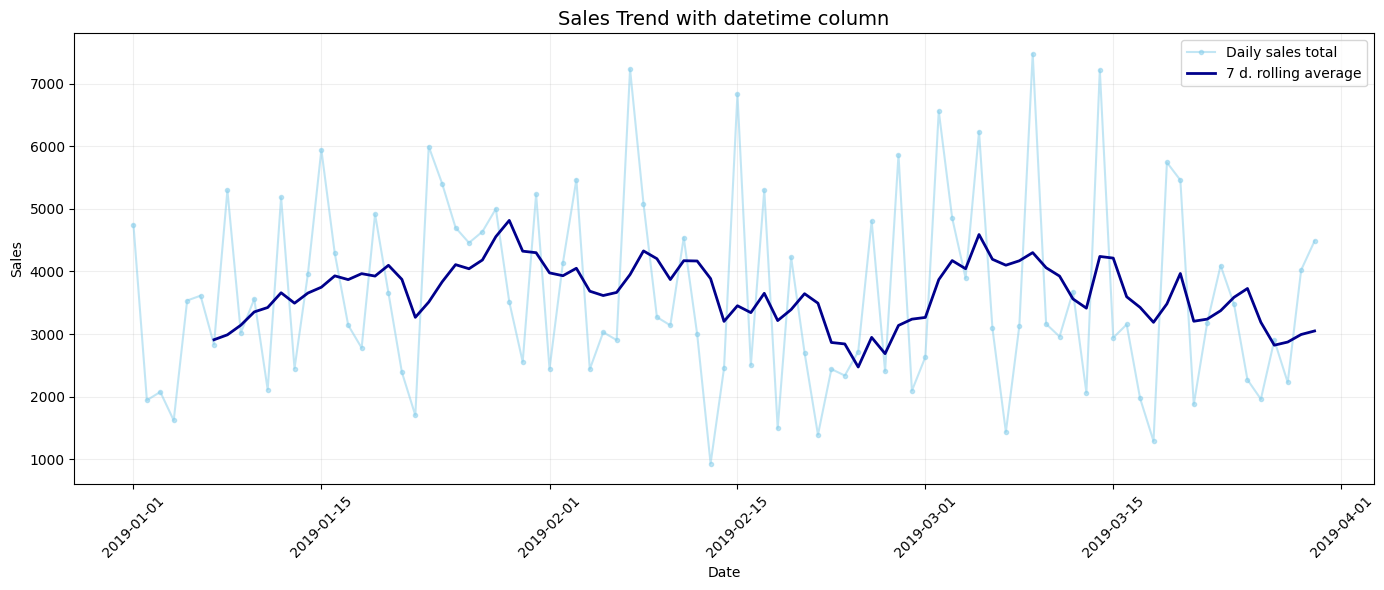

Last predicted value (MA): 3050.78


In [63]:
# 1. Aggregating sales by day

# We use .dt.date to group all hours of the same day into a single data point
daily_sales = df.groupby(df['datetime'].dt.date)['Sales'].sum().sort_index()

# 2. 7-day Rolling average
window = 7
ts_ma = daily_sales.rolling(window=window).mean()

# 3. Visual
plt.figure(figsize=(14, 6))

# Actual daily values
plt.plot(daily_sales.index, daily_sales.values, label='Daily sales total', 
         color='skyblue', alpha=0.5, marker='o', markersize=3)

# Rolling average
plt.plot(ts_ma.index, ts_ma.values, label=f'{window} d. rolling average', 
         color='darkblue', linewidth=2)

plt.title('Sales Trend with datetime column', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45) # Rotating dates to fit
plt.tight_layout()
plt.show()

# 4. Predicted value
print(f"Last predicted value (MA): {ts_ma.iloc[-1]:.2f}")

In this chart, we see an aggregated analysis of sales over time by day. Our dataset covers a relatively short period (2019-01-01 to 2019-03-30), representing the first quarter of the year. This allows us to analyze Q1 behavior and perform a simple forecast for the final day of the period.

The light blue line represents daily total sales, while the dark blue line shows the 7-day moving average. From the daily series, we can clearly observe strong fluctuations, ranging from less than 1,000 to around 7,000 currency units per day. This high variability helps explain the relatively large MAE (~59) observed in the OLS regression model, as even a strong linear model struggles to accurately capture such abrupt changes. Interestingly, the Random Forest model was much less affected by this variability, achieving considerably lower prediction errors (MAE = 5.25, RMSE = 8.11), which indicates that the relationships driving sales may not be purely linear.

Three prominent peaks appear in early February, mid-February, and mid-March, with values exceeding 7,000. These spikes visually highlight the presence of outliers. Although they distort averages and complicate modeling, they also represent significant revenue contributions and are therefore important from a business perspective.

The 7-day moving average smooths out daily noise and provides a clearer view of the underlying trend. It shows that the overall sales level remains relatively stable, with no strong upward or downward trend. The business consistently operates within the range of approximately 3,000 to 4,500 currency units.

A slight cyclical pattern is observable, where sales tend to dip toward the end of the month and recover at the beginning. This may correspond to a typical “payday effect”, where customers reduce spending before salary payments and increase consumption afterward. It is important to stress that this is only an assumption made from a visual, no real credibility was calculated.

No clear weekly seasonality is immediately visible, although this could be further investigated using a more detailed day-of-week analysis.

The last predicted value is 3050.78 currency units, meaning that based on the available data, the supermarket is expected to generate approximately 3050.78 in sales on March 31.
To perform a more accurate and advanced forecast, additional external factors should be taken into account, such as public holidays, vacation periods, weather and temperature changes, previous years’ sales performance, business growth trends, and other relevant external drivers.

C:\Users\linke\AppData\Local\Temp\ipykernel_52388\2035855959.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_analysis.index, y=weekday_analysis.values, palette='viridis')


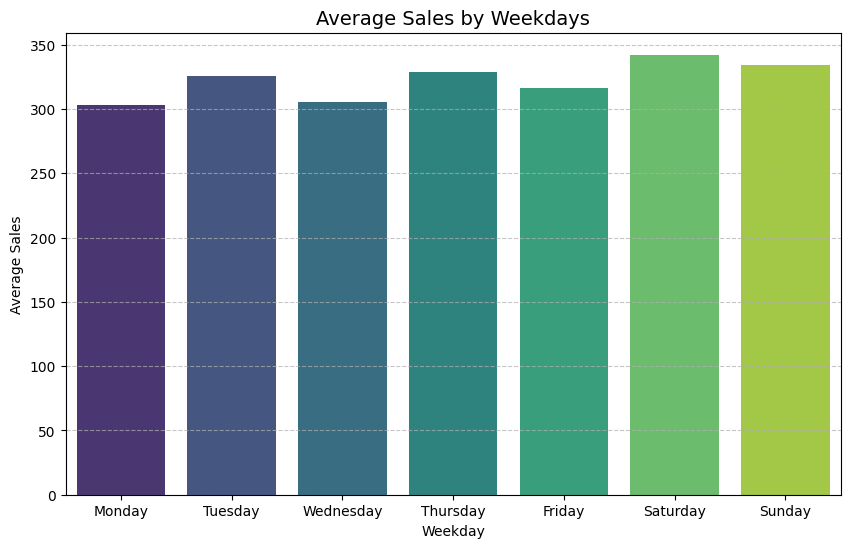

In [64]:

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_analysis = df.groupby('Weekday')['Sales'].mean().reindex(days_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=weekday_analysis.index, y=weekday_analysis.values, palette='viridis')

plt.title('Average Sales by Weekdays', fontsize=14)
plt.ylabel('Average Sales')
plt.xlabel('Weekday')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

We can see only a very small variation across weekdays, where the difference between the weakest day (Monday) and the strongest day (Saturday) is less than 40 currency units. These differences are not statistically or practically significant.

#### 9. Conclusions

Generalized EDA:

- The dataset is relatively large, containing 1000 rows. After data cleaning, we have 19 columns, of which 10 are numerical. There are no missing values. The data covers approximately a quarter (almost 3 months) of supermarket sales.
- The distribution of most variables is not normal. The analyzed variable Sales shows a right-skewed distribution. However, due to the large sample size, we assume approximate normality and select statistical methods accordingly.
- Strong multicollinearity was identified among financial indicators (Sales, cogs, gross income). This is explained by their direct mathematical relationships and a fixed 5% profit margin.
- Sales volume is most strongly correlated with Quantity, while Unit price has a moderate effect. This indicates that basket size is primarily driven by the number of purchased items rather than the price of individual products.
- CI interpretation (Customer satisfaction):
- The calculated 95% confidence interval [6.87, 7.08] for customer ratings (mean ~6.97) confirms that overall customer satisfaction is stable and positive. The narrow interval width suggests that the sample is a good representation of the overall customer population.

Hypothesis testing and interpretation:

- Two hypotheses were tested in this study:

    - H0: The mean purchase amounts (Sales) do not differ between Member and Normal customer groups.

    - H1: The mean purchase amounts (Sales) differ significantly between Member and Normal customer groups.

- The t-test p-value (0.0596) and Mann–Whitney p-value (0.0812) indicate that, although there is a noticeable difference in means (Member mean: 335.74, Normal mean: 306.37) and medians (Member median: 271.95, Normal median: 225.79), this difference does not reach statistical significance.

- Conclusion: Membership status shows a positive tendency on purchase amounts, but high variance within both groups prevents us from concluding that this effect is consistent across all customers.

OLS Regression analysis and The Random Forest analysis summary:

- Metrics:

    - OLS R² (coefficient of determination 0.901): The model explains 90.1% of the variation in sales. Random Forest R² 0.999, explaining 99.9% of the variation in sales.

    - OLS MAE (Mean Absolute Error 59.5): The average prediction error is approximately 59.5 currency units in either direction. Random Forest MAE is much lower, 5.25 curency units in either direction.

    - OLS Coefficients (only two statistically significant variables, also the only 2 important in the Random Forest Feature Importance graph):
    - Quantity coefficient = 58: Holding other variables constant, each additional purchased unit increases total sales by approximately 58 currency units.
    - Unit price coefficient = 5.8: Holding other variables constant, each 1-unit increase in price increases total sales by approximately 5.8 currency units.

- Conclusion: The most important factors affecting sales are quantity (first) and unit price (second). This suggests that sales strategy should primarily focus on increasing basket size (quantity), as it has the strongest impact on revenue.

Time series analysis:

- Time series analysis for the first quarter shows that although there are large fluctuations in daily sales and a wide range of values, the 7-day moving average indicates stable and relatively stationary sales between 3000–4500. The current business model is effective and generates stable revenue.

- No strong patterns are visible, although a slight drop at the end of the month followed by recovery at the beginning of the next month suggests a possible salary-cycle (“payday effect”). No significant weekday seasonality is observed.

- The predicted sales value for March 31, 2019 (3050.78) aligns with this trend, falling within the lower-to-average range of daily sales, consistent with end-of-month behavior.


#### 10. Recomendations for further analysis

- A detailed product-level analysis would be highly valuable. It could help optimize not only revenue but also profit by identifying “golden” products with low costs and high popularity, and further optimizing their sales performance.
- A broader time range (full-year data) would allow for more accurate trend estimation, more reliable forecasting, and better budget planning.
- The Payment method was not analyzed in depth in this study, not because it is irrelevant, but to keep the scope manageable. In future analysis, it would be important to explore potential patterns in payment methods, as this could further support revenue optimization.
- The Rating variable also deserves deeper analysis. Although it was partially explored, its full potential was not utilized. The current customer satisfaction level is moderate, but it could potentially be increased to a strong 7+ (especially since the upper bound of the confidence interval already exceeds 7). Ratings are particularly important for attracting new customers, and we already know that occasional (non-member) customers contribute significantly to high-value transactions that drive revenue.

#### 11. Main insights and business recommendations


- Forecasting:
    - The 7-day moving average (MA) shows that the baseline daily sales level remains stable at around 3050 currency units. Although occasional sharp spikes occur, the overall trend is smooth and stable.
    - Recommendation: It would be more appropriate to use the moving average rather than single-day values when planning future budgets. This approach allows for more accurate cash flow forecasting and helps avoid misleading decisions caused by short-term daily fluctuations, which are clearly present in this dataset.
    
- Product categories (for shelf optimization):
    - The highest revenue is generated by the Food and beverages category, although other categories are relatively close in performance. The only category that stands out as weaker is Health and beauty. For more effective optimization, a deeper product-level analysis should be conducted, including factors such as cogs, expiration time, and other operational constraints.
    - Recommendation: Ensure that Food and beverages and Sports and travel products are always sufficiently stocked, with timely delivery, high quality, and a wide selection, maintaining fully stocked shelves.

- Customer behavior maximization (Up-selling and Cross-selling):
    - Random Forest Feature Importance and OLS Regression coefficients confirm that Quantity has the strongest impact on total sales, even more than unit price.
    - Recommendation: Instead of increasing prices, which may reduce demand, the business should focus on increasing basket size. This can be achieved through promotions that reward higher quantities or basket-level discounts that encourage customers to add additional items to their purchase.

- Loyalty program improvement:
    - It was observed that Normal customers tend to have more frequent large purchases (outliers), while Member customers show more stable spending behavior but fewer extreme high-value transactions.
    - Recommendation: Encourage Normal customers to join the loyalty program, as this stabilizes revenue streams. Additionally, customers with unusually large baskets could be targeted with personalized discounts for future visits to improve retention. This approach could also help create a statistically significant difference between Member and Normal groups (currently borderline, but close).

- Marketing campaign planning:
    - Analysis by weekday shows that customer traffic is very evenly distributed across the week. The common assumption that weekends perform significantly better does not hold in this case.
    - Recommendation: Focus marketing efforts on mid-week promotions, with special attention to increasing sales on Mondays, which represent the weakest performance day.

#### 12. Executive Summary

 1. Key insight: the business is stable
- Fact: Sales over the past 3 months remain stable, with no negative trends. The average daily revenue is approximately ~3100 currency units.
- Meaning: The business model is sustainable and predictable. Historical averages can be reliably used for planning, as market fluctuations are minimal.

2. Revenue driver: basket size
- Fact: The analysis shows that the strongest driver of total revenue is not unit price, but the quantity of items purchased per transaction. Unit price ranks second in importance.
- Recommendation: Focus more on cross-selling strategies (while still maintaining up-selling initiatives). It is recommended to optimize product placement near checkout areas and introduce discount systems for purchasing more than 2–3 units of the same product type.

3. Myth busting: weekday performance
- Fact: The data contradicts the assumption that weekends generate significantly higher traffic. Customer activity is nearly identical across all weekdays.
- Recommendation: Optimize workforce allocation evenly across the week to reduce weekend overload and avoid employee burnout. More balanced scheduling may also improve employee satisfaction, reduce turnover, and lower recruitment and training costs.

4. Main profit categories
- Fact: The Health and beauty category generates the lowest share of total revenue, while all other categories perform similarly.
- Recommendation: Instead of removing this category, consider expanding higher-performing categories such as Food and beverages and Sports and travel, which generate the highest revenue. The goal should be optimization rather than elimination.

5. Customer segment behavior
- Fact: The largest purchases (approximately 800–1000 currency units) are typically made by non-member (“Normal”) customers rather than loyalty program members.
- Recommendation: There is strong potential to convert these high-value customers into loyal members. It is recommended to offer membership immediately after large purchases, including incentives such as discounts for the next visit, to encourage repeat behavior.

Summary:
- The business operates in a stable “steady-state” mode with consistent revenue streams. This is safe and predictable, but it also indicates limited organic growth. The data suggests that meaningful growth potential lies in increasing basket size and converting high-value occasional customers into loyal members, while also attracting new customers, as the analysis shows that occasional shoppers contribute significantly to revenue through infrequent but high-value purchases.